# Brain age prediction from T1 MRI (IXI)

This notebook trains a 3D CNN to predict age from T1-weighted brain MRI, using the IXITiny version of the IXI dataset (healthy adults scanned at three London hospitals). It's evaluated with 5-fold cross-validation, and I also look at age bias, scanner effects and saliency maps.

To run it, pick a GPU runtime and use `Runtime > Run all`. The data downloads automatically. A full run took me about 5.5 hours, mostly because the augmentation runs on the CPU, so set `epochs=2` in the config cell first if you just want to test it.

## Setup

In [ ]:
!pip install -q torchio xlrd

In [ ]:
import glob, os, re, random, time
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter
from sklearn.model_selection import StratifiedKFold, train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchio as tio

CFG = dict(
    seed=42,
    n_folds=5,
    val_frac=0.15,      # fraction of each fold's training data used for validation
    epochs=60,
    batch_size=8,
    lr=5e-4,
    weight_decay=1e-4,
)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for d in ['figures', 'results', 'models']:
    os.makedirs(d, exist_ok=True)
print('Device:', device)

Device: cuda


## Download the data

This gets the IXITiny scans through TorchIO and the IXI demographics spreadsheet, which has the ages.

In [ ]:
# 566 preprocessed T1-weighted scans (83 x 44 x 55 voxels)
_ = tio.datasets.IXITiny('ixi_tiny', download=True)

# Official IXI demographics spreadsheet (contains age)
!wget -q -nc http://biomedic.doc.ic.ac.uk/brain-development/downloads/IXI/IXI.xls
print('IXI.xls downloaded:', os.path.exists('IXI.xls'))

IXI.xls downloaded: True


## Match scans to ages

The subject ID is in each file name (e.g. `IXI002-Guys-0828` is subject 2), and the site name comes from the same place.

Scans found: 566 | with age: 549
      count  mean   std   min   25%   50%   75%   max
site                                                 
Guys  304.0  51.1  15.9  20.1  37.6  53.6  63.3  86.2
HH    177.0  47.4  16.6  20.2  33.5  48.1  61.8  81.9
IOP    68.0  42.4  16.6  20.0  29.6  36.3  49.8  86.3


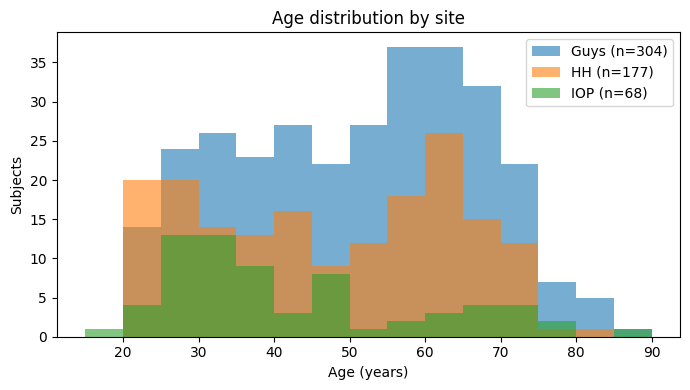

In [ ]:
demo = pd.read_excel('IXI.xls')
demo = demo.dropna(subset=['AGE']).drop_duplicates(subset='IXI_ID', keep='first')
age_of = dict(zip(demo['IXI_ID'].astype(int), demo['AGE'].astype(float)))

files = sorted(f for f in glob.glob('ixi_tiny/**/*.nii.gz', recursive=True)
               if 'label' not in os.path.basename(f).lower()
               and 'label' not in os.path.dirname(f).lower())

records = []
for f in files:
    name = os.path.basename(f)
    m = re.search(r'IXI(\d{3})', name)
    if m and int(m.group(1)) in age_of:
        sid = int(m.group(1))
        site = name.split('-')[1] if '-' in name else 'unknown'
        records.append({'path': f, 'id': sid, 'age': age_of[sid], 'site': site})

df = pd.DataFrame(records).sort_values('id').reset_index(drop=True)
ages = df['age'].values.astype(np.float32)
print(f'Scans found: {len(files)} | with age: {len(df)}')
print(df.groupby('site')['age'].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for site, g in df.groupby('site'):
    ax.hist(g['age'], bins=np.arange(15, 95, 5), alpha=0.6, label=f'{site} (n={len(g)})')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Subjects'); ax.set_title('Age distribution by site'); ax.legend()
plt.tight_layout(); plt.savefig('figures/age_distribution.png', dpi=150); plt.show()

## Load the scans

The scans are small, so I load all of them into memory once. Each one is z-score normalised. The left-right axis is read from the image header so the flips and plots use the right direction.

Orientation: ('S', 'R', 'A') | left-right axis: 1 | superior-inferior axis: 0
Volumes tensor: (549, 1, 83, 44, 55)


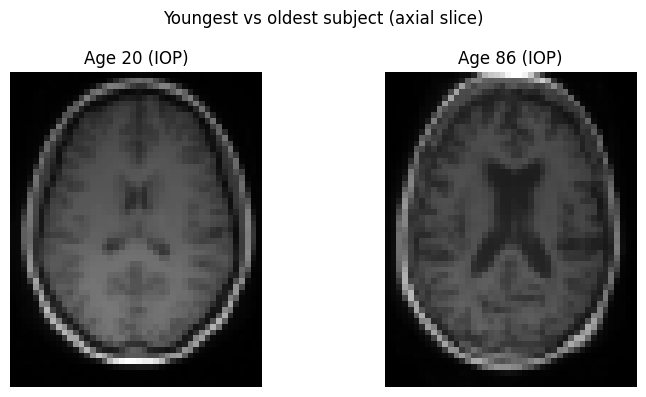

In [ ]:
# Find anatomical axes from the image header (so flips and slices are correct)
codes = nib.aff2axcodes(nib.load(df.path[0]).affine)
LR_AXIS = next(i for i, c in enumerate(codes) if c in ('L', 'R'))
SI_AXIS = next(i for i, c in enumerate(codes) if c in ('S', 'I'))
print('Orientation:', codes, '| left-right axis:', LR_AXIS, '| superior-inferior axis:', SI_AXIS)

def load_volume(path):
    v = nib.load(path).get_fdata().astype(np.float32)
    return (v - v.mean()) / (v.std() + 1e-8)     # per-scan z-score

volumes = torch.stack([torch.from_numpy(load_volume(p)) for p in df.path])[:, None]   # N, 1, X, Y, Z
print('Volumes tensor:', tuple(volumes.shape))

def mid_slice(vol, axis):
    return np.rot90(np.take(vol, vol.shape[axis] // 2, axis=axis))

young, old = df.age.idxmin(), df.age.idxmax()
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for a, i in zip(ax, [young, old]):
    a.imshow(mid_slice(volumes[i, 0].numpy(), SI_AXIS), cmap='gray'); a.axis('off')
    a.set_title(f'Age {df.age[i]:.0f} ({df.site[i]})')
plt.suptitle('Youngest vs oldest subject (axial slice)')
plt.tight_layout(); plt.savefig('figures/example_scans.png', dpi=150); plt.show()

## Dataset and augmentation

For training: random left-right flip, small random affine (rotation, scaling, shift) and some Gaussian noise. Ages are standardised with each fold's training mean and SD.

In [ ]:
augment = tio.Compose([
    tio.RandomAffine(scales=0.05, degrees=5, translation=3, p=0.75),
    tio.RandomNoise(std=(0, 0.05), p=0.5),
])

class BrainAgeDataset(Dataset):
    def __init__(self, idx, age_mean, age_std, train=False):
        self.idx = np.asarray(idx)
        self.y = torch.tensor((ages[self.idx] - age_mean) / age_std, dtype=torch.float32)
        self.train = train
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        x = volumes[self.idx[i]]
        if self.train:
            if random.random() < 0.5:
                x = torch.flip(x, dims=[LR_AXIS + 1])
            x = augment(x).float()
        return x, self.y[i]

## Model

A plain 3D CNN: four blocks of two convolutions plus max-pooling, then global average pooling, dropout and one linear output.

In [ ]:
def block(cin, cout):
    return nn.Sequential(
        nn.Conv3d(cin, cout, 3, padding=1), nn.BatchNorm3d(cout), nn.ReLU(inplace=True),
        nn.Conv3d(cout, cout, 3, padding=1), nn.BatchNorm3d(cout), nn.ReLU(inplace=True),
        nn.MaxPool3d(2))

class BrainAgeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(block(1, 16), block(16, 32), block(32, 64), block(64, 128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool3d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, 1))
    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)

print(f'Parameters: {sum(p.numel() for p in BrainAgeCNN().parameters()):,}')

Parameters: 879,825


## Training and prediction

L1 loss, AdamW, cosine learning rate schedule. I keep the weights from the epoch with the lowest validation MAE.

In [ ]:
def make_loader(idx, age_mean, age_std, train=False):
    ds = BrainAgeDataset(idx, age_mean, age_std, train=train)
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=train, num_workers=2,
                      pin_memory=(device.type == 'cuda'))

def predict(model, idx, age_mean, age_std):
    model.eval(); preds = []
    with torch.no_grad():
        for x, _ in make_loader(idx, age_mean, age_std):
            preds.append(model(x.to(device)).cpu())
    return torch.cat(preds).numpy() * age_std + age_mean

def train_fold(train_idx, val_idx, fold):
    age_mean, age_std = ages[train_idx].mean(), ages[train_idx].std()
    model = BrainAgeCNN().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG['epochs'])
    loss_fn = nn.L1Loss()
    train_dl = make_loader(train_idx, age_mean, age_std, train=True)
    history, best_mae, best_state = [], float('inf'), None

    for epoch in range(1, CFG['epochs'] + 1):
        model.train(); running = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); loss = loss_fn(model(x), y); loss.backward(); opt.step()
            running += loss.item() * len(x)
        sched.step()
        train_mae = running / len(train_idx) * age_std
        val_mae = np.abs(predict(model, val_idx, age_mean, age_std) - ages[val_idx]).mean()
        history.append((train_mae, val_mae))
        if val_mae < best_mae:
            best_mae = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == 1:
            print(f'  fold {fold} | epoch {epoch:3d} | train MAE {train_mae:5.2f} | val MAE {val_mae:5.2f}')

    model.load_state_dict(best_state)
    return model, age_mean, age_std, history

## 5-fold cross-validation

Folds are stratified by age, so every subject is tested exactly once. Inside each fold, 15% of the training part is used for validation, both to pick the best epoch and to fit the bias correction (a linear fit of gap vs age, following Smith et al. 2019). The test fold isn't touched until the end.

In [ ]:
age_bins = pd.qcut(df['age'], q=5, labels=False).values
skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

oof = df[['id', 'age', 'site']].copy()
oof['fold'], oof['pred'], oof['pred_corrected'] = -1, np.nan, np.nan
fold_rows, histories, fold_test_idx = [], {}, {}

for fold, (trval_idx, test_idx) in enumerate(skf.split(df, age_bins), start=1):
    t0 = time.time(); set_seed(CFG['seed'] + fold)
    train_idx, val_idx = train_test_split(trval_idx, test_size=CFG['val_frac'],
                                          stratify=age_bins[trval_idx], random_state=CFG['seed'])
    print(f'Fold {fold}: train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}')
    model, age_mean, age_std, hist = train_fold(train_idx, val_idx, fold)
    histories[fold], fold_test_idx[fold] = hist, test_idx
    torch.save(model.state_dict(), f'models/fold{fold}.pt')

    # Age-bias correction fitted on validation data only
    val_true = ages[val_idx]
    slope, intercept = np.polyfit(val_true, predict(model, val_idx, age_mean, age_std) - val_true, 1)

    true = ages[test_idx]
    pred = predict(model, test_idx, age_mean, age_std)
    pred_c = pred - (slope * true + intercept)
    gap, gap_c = pred - true, pred_c - true

    fold_rows.append(dict(
        fold=fold, n_test=len(test_idx),
        MAE=np.abs(gap).mean(),
        RMSE=np.sqrt((gap ** 2).mean()),
        r=stats.pearsonr(true, pred)[0],
        R2=1 - (gap ** 2).sum() / ((true - true.mean()) ** 2).sum(),
        baseline_MAE=np.abs(true - ages[train_idx].mean()).mean(),
        gap_age_r_before=stats.pearsonr(true, gap)[0],
        gap_age_r_after=stats.pearsonr(true, gap_c)[0],
    ))
    oof.loc[test_idx, 'fold'] = fold
    oof.loc[test_idx, 'pred'] = pred
    oof.loc[test_idx, 'pred_corrected'] = pred_c
    print(f'  -> fold {fold} test MAE {fold_rows[-1]["MAE"]:.2f} years  ({(time.time() - t0) / 60:.1f} min)\n')

oof['gap'] = oof['pred'] - oof['age']
oof['gap_corrected'] = oof['pred_corrected'] - oof['age']
oof.to_csv('results/oof_predictions.csv', index=False)

Fold 1: train 373 | val 66 | test 110
  fold 1 | epoch   1 | train MAE 13.76 | val MAE 72.80
  fold 1 | epoch  10 | train MAE  9.78 | val MAE 12.26
  fold 1 | epoch  20 | train MAE  9.30 | val MAE 11.28
  fold 1 | epoch  30 | train MAE  7.74 | val MAE  8.03
  fold 1 | epoch  40 | train MAE  7.41 | val MAE  8.39
  fold 1 | epoch  50 | train MAE  6.41 | val MAE  7.42
  fold 1 | epoch  60 | train MAE  5.81 | val MAE  6.17
  -> fold 1 test MAE 6.05 years  (65.7 min)

Fold 2: train 373 | val 66 | test 110
  fold 2 | epoch   1 | train MAE 13.69 | val MAE 31.71
  fold 2 | epoch  10 | train MAE 10.02 | val MAE  8.58
  fold 2 | epoch  20 | train MAE  8.96 | val MAE  7.99
  fold 2 | epoch  30 | train MAE  7.68 | val MAE  5.50
  fold 2 | epoch  40 | train MAE  7.32 | val MAE  5.75
  fold 2 | epoch  50 | train MAE  6.79 | val MAE  5.22
  fold 2 | epoch  60 | train MAE  5.68 | val MAE  5.03
  -> fold 2 test MAE 5.74 years  (67.5 min)

Fold 3: train 373 | val 66 | test 110
  fold 3 | epoch   1 | tra

## Results

In [ ]:
folds = pd.DataFrame(fold_rows)
folds.to_csv('results/fold_metrics.csv', index=False)
print(folds.round(3).to_string(index=False))

labels = {
    'MAE': ('MAE (years)', 2), 'RMSE': ('RMSE (years)', 2), 'r': ('Pearson r', 3), 'R2': ('R²', 3),
    'baseline_MAE': ('Baseline MAE, predict mean age (years)', 2),
    'gap_age_r_before': ('Gap–age correlation, before bias correction', 2),
    'gap_age_r_after': ('Gap–age correlation, after bias correction', 2),
}
lines = [f'| Metric | Mean ± SD over {CFG["n_folds"]} folds |', '|---|---|']
for k, (label, dp) in labels.items():
    lines.append(f'| {label} | {folds[k].mean():.{dp}f} ± {folds[k].std():.{dp}f} |')
summary_md = '\n'.join(lines)
with open('results/summary.md', 'w') as f:
    f.write(summary_md + '\n')
print('\nCopy this table into your README:\n')
print(summary_md)

 fold  n_test   MAE  RMSE     r    R2  baseline_MAE  gap_age_r_before  gap_age_r_after
    1     110 6.053 7.926 0.888 0.768        14.451            -0.481           -0.104
    2     110 5.740 7.331 0.906 0.815        15.076            -0.293            0.139
    3     110 5.736 7.527 0.896 0.786        14.312            -0.222           -0.048
    4     110 5.204 6.686 0.917 0.822        14.019            -0.174            0.385
    5     109 6.224 7.882 0.886 0.771        14.423            -0.280            0.079

Copy this table into your README:

| Metric | Mean ± SD over 5 folds |
|---|---|
| MAE (years) | 5.79 ± 0.39 |
| RMSE (years) | 7.47 ± 0.50 |
| Pearson r | 0.899 ± 0.013 |
| R² | 0.793 ± 0.025 |
| Baseline MAE, predict mean age (years) | 14.46 ± 0.39 |
| Gap–age correlation, before bias correction | -0.29 ± 0.12 |
| Gap–age correlation, after bias correction | 0.09 ± 0.19 |


## Plots: learning curves, predictions and bias correction

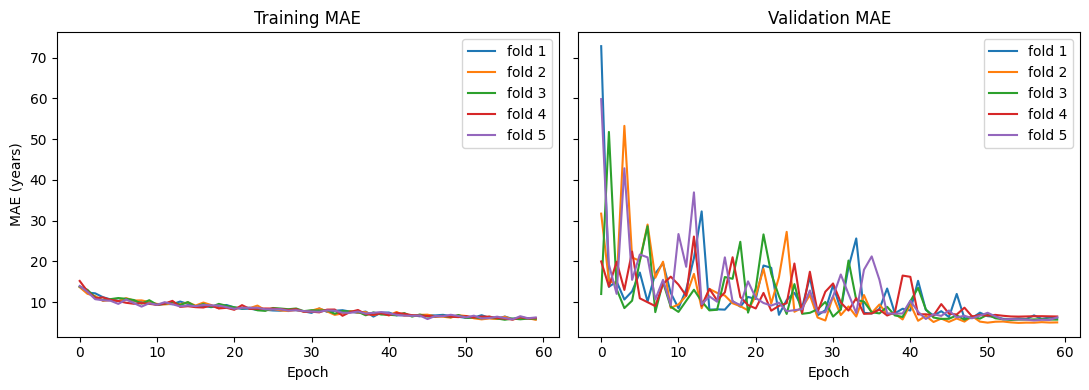

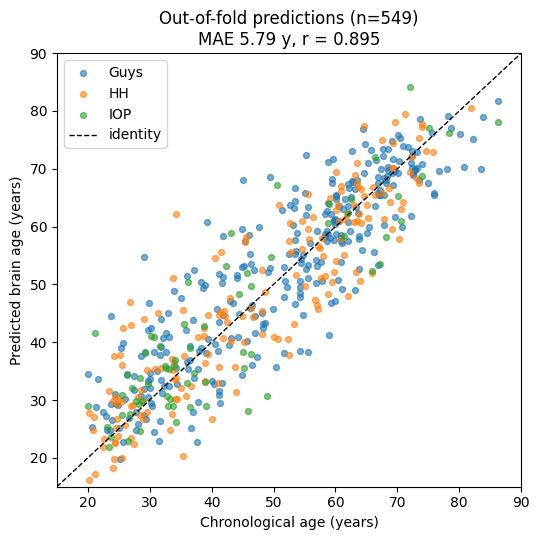

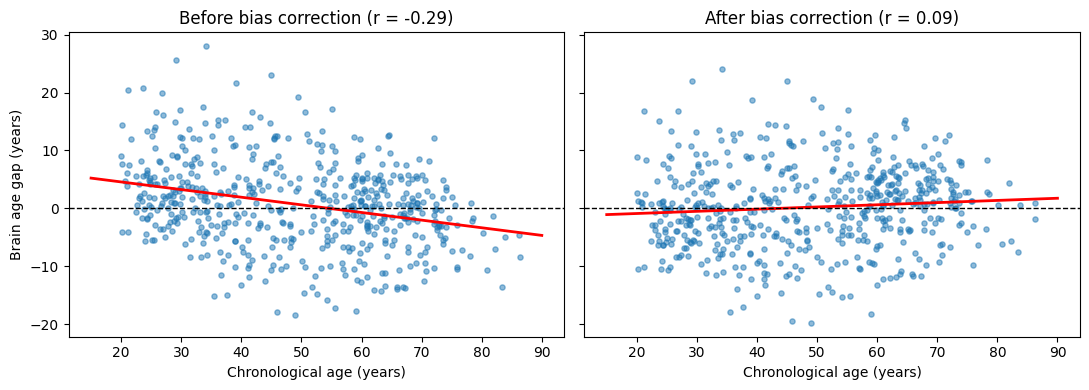

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for fold, h in histories.items():
    h = np.array(h)
    ax[0].plot(h[:, 0], label=f'fold {fold}'); ax[1].plot(h[:, 1], label=f'fold {fold}')
ax[0].set_title('Training MAE'); ax[1].set_title('Validation MAE')
for a in ax: a.set_xlabel('Epoch'); a.legend()
ax[0].set_ylabel('MAE (years)')
plt.tight_layout(); plt.savefig('figures/learning_curves.png', dpi=150); plt.show()

overall_mae = np.abs(oof.gap).mean(); overall_r = stats.pearsonr(oof.age, oof.pred)[0]
lim = [15, 90]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for site, g in oof.groupby('site'):
    ax.scatter(g.age, g.pred, alpha=0.6, s=18, label=site)
ax.plot(lim, lim, 'k--', lw=1, label='identity')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel('Chronological age (years)'); ax.set_ylabel('Predicted brain age (years)')
ax.set_title(f'Out-of-fold predictions (n={len(oof)})\nMAE {overall_mae:.2f} y, r = {overall_r:.3f}'); ax.legend()
plt.tight_layout(); plt.savefig('figures/pred_vs_true.png', dpi=150); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, col, title in zip(ax, ['gap', 'gap_corrected'], ['Before bias correction', 'After bias correction']):
    r = stats.pearsonr(oof.age, oof[col])[0]
    a.scatter(oof.age, oof[col], alpha=0.5, s=14)
    slope, intercept = np.polyfit(oof.age, oof[col], 1)
    xs = np.array(lim); a.plot(xs, slope * xs + intercept, 'r-', lw=2)
    a.axhline(0, color='k', ls='--', lw=1)
    a.set_title(f'{title} (r = {r:.2f})'); a.set_xlabel('Chronological age (years)')
ax[0].set_ylabel('Brain age gap (years)')
plt.tight_layout(); plt.savefig('figures/bias_correction.png', dpi=150); plt.show()

## Scanner (site) analysis

Two questions: is the model less accurate at some sites, and does the scanner shift the predicted brain age? I use the bias-corrected gap for the second one, and a Kruskal-Wallis test for both.

        n  mean_age   MAE  mean_corrected_gap
site                                         
Guys  304     51.08  5.80                0.91
HH    177     47.40  5.58               -0.51
IOP    68     42.37  6.29               -1.09 

Kruskal-Wallis, absolute error across sites:  p = 0.5105
Kruskal-Wallis, corrected gap across sites:   p = 0.0210


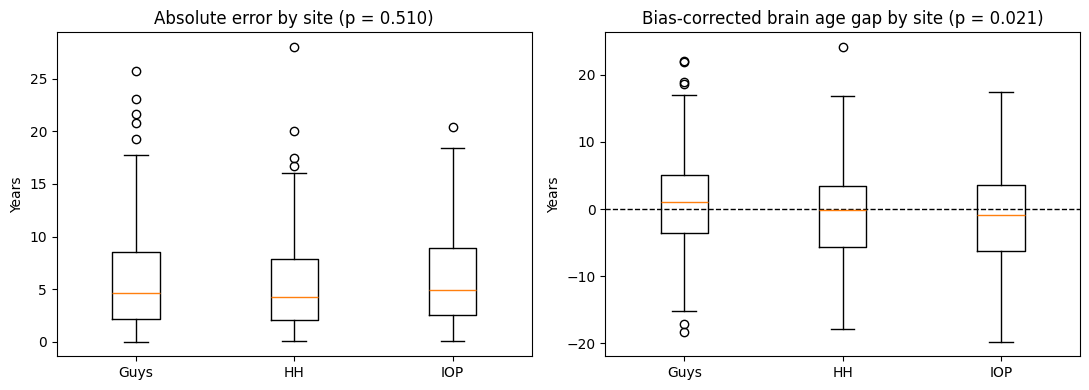

In [ ]:
oof['abs_err'] = oof['gap'].abs()
site_table = oof.groupby('site').agg(
    n=('age', 'size'), mean_age=('age', 'mean'),
    MAE=('abs_err', 'mean'), mean_corrected_gap=('gap_corrected', 'mean')).round(2)
site_table.to_csv('results/site_analysis.csv')
print(site_table, '\n')

groups = [g for _, g in oof.groupby('site')]
p_err = stats.kruskal(*[g.abs_err for g in groups]).pvalue
p_gap = stats.kruskal(*[g.gap_corrected for g in groups]).pvalue
print(f'Kruskal-Wallis, absolute error across sites:  p = {p_err:.4f}')
print(f'Kruskal-Wallis, corrected gap across sites:   p = {p_gap:.4f}')

sites = sorted(oof.site.unique())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([oof.loc[oof.site == s, 'abs_err'] for s in sites])
ax[0].set_xticks(range(1, len(sites) + 1), sites)
ax[0].set_title(f'Absolute error by site (p = {p_err:.3f})'); ax[0].set_ylabel('Years')
ax[1].boxplot([oof.loc[oof.site == s, 'gap_corrected'] for s in sites])
ax[1].set_xticks(range(1, len(sites) + 1), sites)
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set_title(f'Bias-corrected brain age gap by site (p = {p_gap:.3f})'); ax[1].set_ylabel('Years')
plt.tight_layout(); plt.savefig('figures/site_effect.png', dpi=150); plt.show()

## Saliency maps

Gradient saliency for the youngest, median and oldest subject in fold 1's test set. Bright areas are the voxels that change the prediction most. This is only a rough qualitative check.

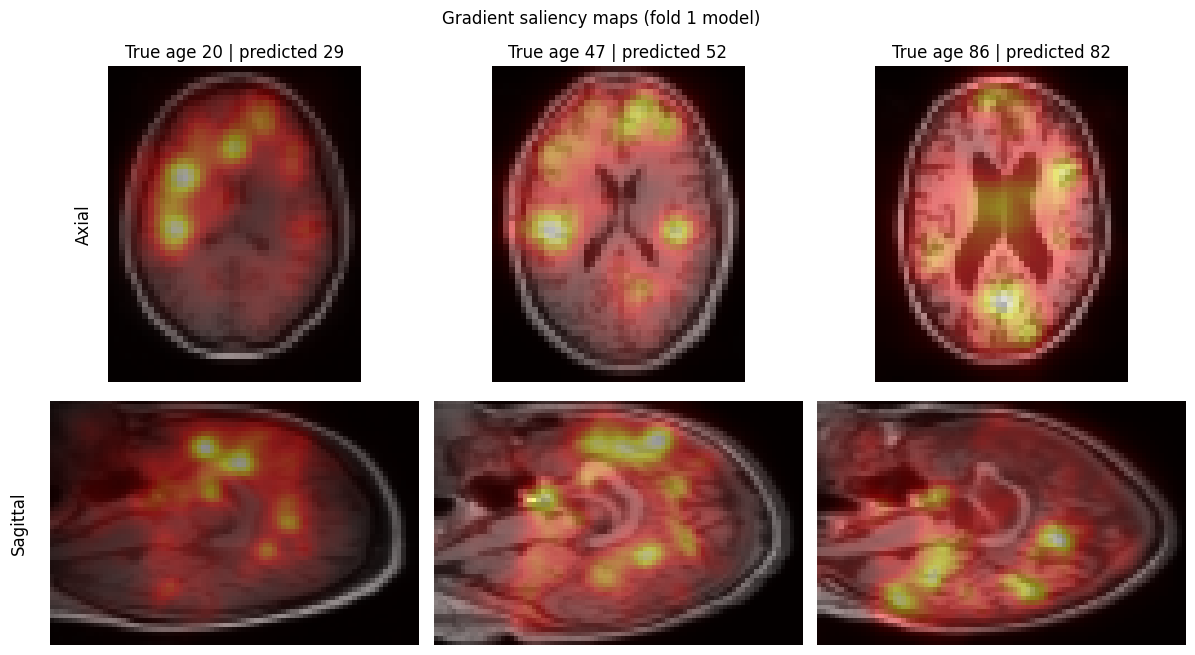

In [ ]:
model = BrainAgeCNN().to(device)
model.load_state_dict(torch.load('models/fold1.pt', map_location=device)); model.eval()

test_idx = fold_test_idx[1]
order = test_idx[np.argsort(ages[test_idx])]
examples = [order[0], order[len(order) // 2], order[-1]]

def saliency(i):
    x = volumes[i:i + 1].clone().to(device).requires_grad_(True)
    model(x).sum().backward()
    s = gaussian_filter(x.grad.abs()[0, 0].cpu().numpy(), sigma=1.5)
    return s / (s.max() + 1e-8)

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for col, i in enumerate(examples):
    vol, sal = volumes[i, 0].numpy(), saliency(i)
    pred_age = oof.loc[i, 'pred']
    for row, axis in enumerate([SI_AXIS, LR_AXIS]):
        a = ax[row, col]
        a.imshow(mid_slice(vol, axis), cmap='gray')
        a.imshow(mid_slice(sal, axis), cmap='hot', alpha=0.45); a.axis('off')
    ax[0, col].set_title(f'True age {ages[i]:.0f} | predicted {pred_age:.0f}')
for row, name in enumerate(['Axial', 'Sagittal']):
    ax[row, 0].text(-0.06, 0.5, name, transform=ax[row, 0].transAxes, rotation=90, va='center', ha='right', fontsize=12)
plt.suptitle('Gradient saliency maps (fold 1 model)')
plt.tight_layout(); plt.savefig('figures/saliency.png', dpi=150); plt.show()

## Save the figures and results

In [ ]:
!zip -q -r brain_age_outputs.zip figures results
try:
    from google.colab import files
    files.download('brain_age_outputs.zip')
except ImportError:
    print('Not running in Colab: outputs are in brain_age_outputs.zip')

## Limitations and next steps

- IXITiny is heavily downsampled, which limits accuracy. Full-resolution IXI would be the obvious next thing to try.
- Everyone here is healthy, so the brain age gap isn't tested against any disease. A dataset like OASIS (with Alzheimer's patients) would let me check that.
- The bias correction is fitted on only 66 subjects per fold, so it isn't very stable.
- I'd like to compare with SFCN (Peng et al., 2021) and try training on two sites and testing on the third.